### Section 1 — Question 1  
Import the healthCareVSlifeExpectancyV3.xlsx file to a dataframe.


In [22]:
import pandas as pd

df = pd.read_excel("healthCareVSlifeExpectancyV3.xlsx")


### Section 1 — Question 2  
Print out the first few rows of the dataset and generate some summary information of the data.


In [23]:
df.head()
df.describe()


,lifeExpectancy,healthExpenditurePerCapita,totalPop,popDensity,gdp,gdpPerCapita
count,186.000000,186.000000,1.860000e+02,186.000000,1.860000e+02,186.000000
mean,71.723898,1371.600848,3.898092e+07,331.704011,4.001144e+11,14180.874579
std,7.890849,1669.504010,1.452811e+08,1546.132824,1.520969e+12,21634.599088
min,50.881000,31.855776,1.000000e+04,1.841678,3.806102e+07,227.403625
25%,66.479250,220.848703,1.960500e+06,33.798594,7.744318e+09,1720.686535
50%,73.135000,743.277702,8.202500e+06,78.694513,2.725390e+10,5385.208558
75%,76.881500,1702.910112,2.764725e+07,191.267109,1.923050e+11,15112.628422
max,85.739000,9535.945335,1.406848e+09,17203.184090,1.667270e+13,164789.473700


### Section 1 — Question 3  
Create a linear regression predicting life expectancy from health expenditure per capita.  
Use the statsmodels library. Print a summary of your results.


In [24]:
import statsmodels.api as sm

x = df["healthExpenditurePerCapita"]
y = df["lifeExpectancy"]

x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         lifeExpectancy   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.464
Method:                 Least Squares   F-statistic:                     161.2
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           6.17e-27
Time:                        18:43:24   Log-Likelihood:                -589.12
No. Observations:                 186   AIC:                             1182.
Df Residuals:                     184   BIC:                             1189.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         67.2937      0.549    122.629      0.000      66.211      68.376
healthExpenditurePerCapita     0.0032      0.000     12.697      0.000       0.003       0.004
==============================================================================
Omnibus:                       26.729   Durbin-Watson:                   1.968
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               33.375
Skew:                          -1.001   Prob(JB):                     5.66e-08
Kurtosis:                       3.545   Cond. No.                     2.79e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.79e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Interpretation:**  
The regression shows that health expenditure per capita has a significant positive effect on life expectancy (p < 0.001).  
For every one unit increase in health expenditure per capita, life expectancy increases by approximately 0.003 years.  
The model explains about 46.7% of the variance in life expectancy (R² = 0.467).


### Section 1 — Question 4  
Create a scatterplot in blue of the data with life expectancy on the y-axis and health expenditure per capita on the x-axis.  
Add a red regression line using seaborn’s regplot, and set the ci parameter to None.


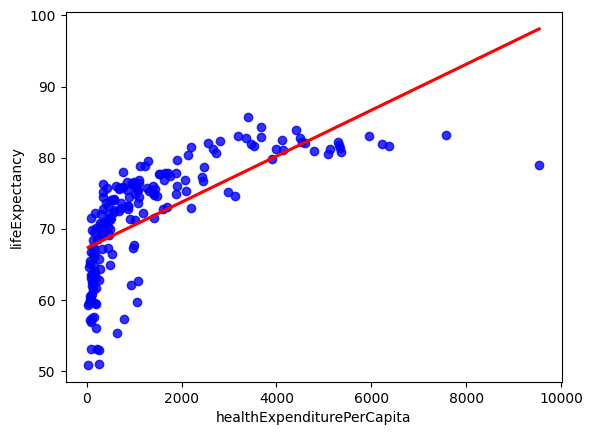

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(x="healthExpenditurePerCapita", y="lifeExpectancy", data=df, color="blue", line_kws={"color": "red"}, ci=None)
plt.show()


### Section 1 — Question 5  
Check if your residuals are normally distributed using a QQ-plot from the scipy library.  
Does your model meet the linearity assumptions for linear regression?


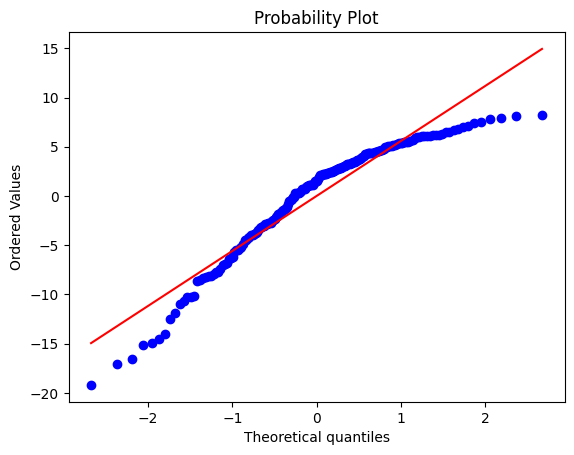

In [26]:
import scipy.stats as stats
import matplotlib.pyplot as plt

residuals = model.resid
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()


**Interpretation:**  
The QQ-plot shows that most residuals follow the diagonal line, but the tails deviate slightly.  
This means the residuals are approximately normal, so the linearity assumption is mostly met.


### Section 1 — Question 6  
Use the same data to create a polynomial regression of the relationship with degree 4.  
Print out the coefficients of your model and the R² value.


In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

x = df[["healthExpenditurePerCapita"]]
y = df["lifeExpectancy"]

pr = PolynomialFeatures(degree=4)
x_poly = pr.fit_transform(x)

lr_poly = LinearRegression()
lr_poly.fit(x_poly, y)

print("Coefficients:", lr_poly.coef_)
print("Intercept:", lr_poly.intercept_)
print("R^2:", r2_score(y, lr_poly.predict(x_poly)))


Coefficients: [ 0.00000000e+00  1.61979432e-02 -5.25831091e-06  7.43750079e-10
 -3.68961487e-14]
Intercept: 61.97840657829077
R^2: 0.6711092855904293


**Explanation:**  
There are 5 coefficients because the polynomial regression includes one intercept and four power terms (x, x², x³, x⁴).  
This 4th-degree model captures the nonlinear relationship between life expectancy and health expenditure more accurately.


### Section 1 — Question 7  
Create a plot showing your polynomial regression fit on top of a scatterplot of your data.


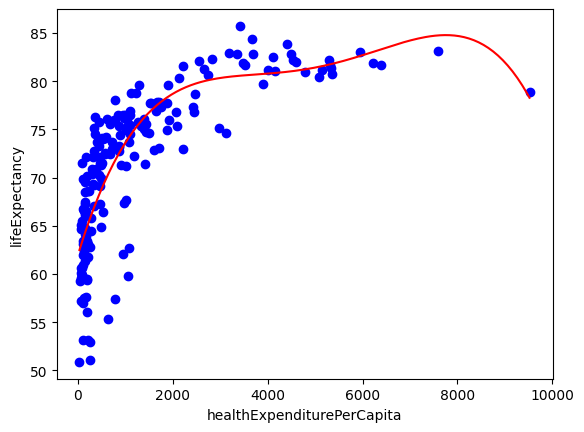

In [28]:
import numpy as np
import matplotlib.pyplot as plt

x_max = max(x["healthExpenditurePerCapita"])
x_min = min(x["healthExpenditurePerCapita"])
x_range = np.arange(x_min, x_max, np.round((x_max - x_min)/len(x)))
x_range_poly = pr.fit_transform(x_range.reshape(-1,1))
y_pred_poly_fit = lr_poly.predict(x_range_poly)

plt.scatter(x, y, color="blue")
plt.plot(x_range, y_pred_poly_fit, color="red")
plt.xlabel("healthExpenditurePerCapita")
plt.ylabel("lifeExpectancy")
plt.show()


### Section 1 — Question 8  
Use the same dataset to create a multiple linear regression model using statsmodels from all of the predictors (do not include any polynomial inputs).  
Print out a summary of your results.


In [29]:
x = df[["healthExpenditurePerCapita", "totalPop", "popDensity", "gdp", "gdpPerCapita"]]
y = df["lifeExpectancy"]

x = sm.add_constant(x)
multi_model = sm.OLS(y, x).fit()
multi_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         lifeExpectancy   R-squared:                       0.496
Model:                            OLS   Adj. R-squared:                  0.482
Method:                 Least Squares   F-statistic:                     35.43
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           3.87e-25
Time:                        18:43:25   Log-Likelihood:                -583.92
No. Observations:                 186   AIC:                             1180.
Df Residuals:                     180   BIC:                             1199.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         66.6350      0.594    112.091      0.000      65.462      67.808
healthExpenditurePerCapita     0.0042      0.001      5.977      0.000       0.003       0.006
totalPop                    7.301e-09   3.65e-09      1.999      0.047    9.55e-11    1.45e-08
popDensity                     0.0006      0.000      1.632      0.104      -0.000       0.001
gdp                        -1.172e-12   4.22e-13     -2.777      0.006      -2e-12   -3.39e-13
gdpPerCapita               -5.247e-05   5.45e-05     -0.962      0.337      -0.000    5.51e-05
==============================================================================
Omnibus:                       18.495   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               21.681
Skew:                          -0.836   Prob(JB):                     1.96e-05
Kurtosis:                       3.054   Cond. No.                     2.24e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.24e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Section 1 — Question 9  
Of the three models you created, which would you choose and why?


Among the three models, the polynomial regression model (degree = 4) would be chosen.  
It has the highest R² value (0.671) compared to the simple linear regression (0.467) and the multiple linear regression (0.496).  
The polynomial model captures the non-linear relationship between life expectancy and health expenditure more accurately,  
as shown in the curved fit on the scatterplot. Therefore, it provides the best balance between explanatory power and interpretability.


### Section 1 — Question 10  
Check for outliers in your data by creating a plot of residuals vs fitted values.  
Use residplot from seaborn.


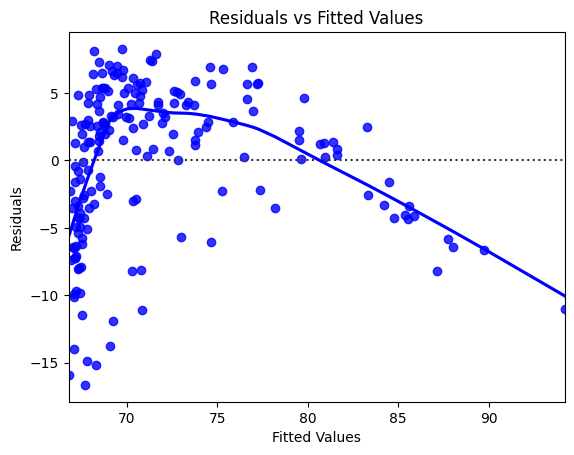

In [30]:
sns.residplot(x=multi_model.fittedvalues, y=multi_model.resid, lowess=True, color="blue")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


### Section 1 — Question 11  
Re-run your multiple regression model removing the largest outlier.  
Did the results improve?


In [31]:
# Find and remove the largest residual
df_no_outlier = df.drop(index=abs(multi_model.resid).idxmax())

x_no_outlier = df_no_outlier[["healthExpenditurePerCapita", "totalPop", "popDensity", "gdp", "gdpPerCapita"]]
y_no_outlier = df_no_outlier["lifeExpectancy"]

x_no_outlier = sm.add_constant(x_no_outlier)
multi_model_no_outlier = sm.OLS(y_no_outlier, x_no_outlier).fit()
multi_model_no_outlier.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:         lifeExpectancy   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     36.03
Date:                Mon, 20 Oct 2025   Prob (F-statistic):           2.01e-25
Time:                        18:43:25   Log-Likelihood:                -576.72
No. Observations:                 185   AIC:                             1165.
Df Residuals:                     179   BIC:                             1185.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         66.7952      0.584    114.367      0.000      65.643      67.948
healthExpenditurePerCapita     0.0042      0.001      6.017      0.000       0.003       0.006
totalPop                    7.003e-09   3.57e-09      1.959      0.052   -4.96e-11    1.41e-08
popDensity                     0.0006      0.000      1.635      0.104      -0.000       0.001
gdp                        -1.147e-12   4.13e-13     -2.777      0.006   -1.96e-12   -3.32e-13
gdpPerCapita               -5.099e-05   5.34e-05     -0.956      0.340      -0.000    5.43e-05
==============================================================================
Omnibus:                       17.015   Durbin-Watson:                   1.910
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               19.771
Skew:                          -0.800   Prob(JB):                     5.09e-05
Kurtosis:                       2.956   Cond. No.                     2.25e+12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.25e+12. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Section 2 — Question 1  
Print out the first few rows of data and use describe to examine the summary statistics of the continuous variables.


In [32]:
df1 = pd.read_csv("cars.csv")
df1.head()
df1.describe()


,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,2013.358199,5.873838e+04,5.278735,9.479468
std,3.269742,9.126884e+04,0.808840,11.187917
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.640000
75%,2016.000000,7.300000e+04,5.000000,9.950000
max,2019.000000,6.500000e+06,10.000000,160.000000


### Section 2 — Question 2  
Transform Price so that it looks more normal.  
Produce histograms of the variable before and after transformation.


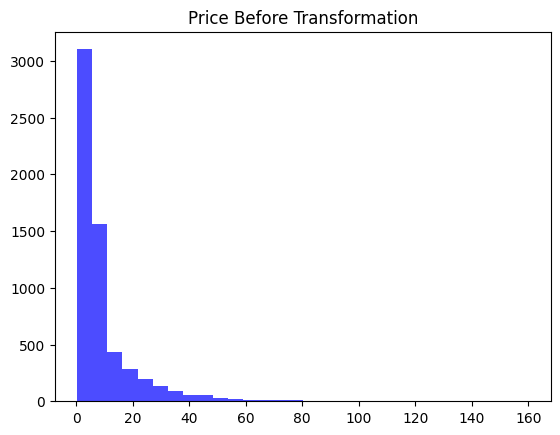

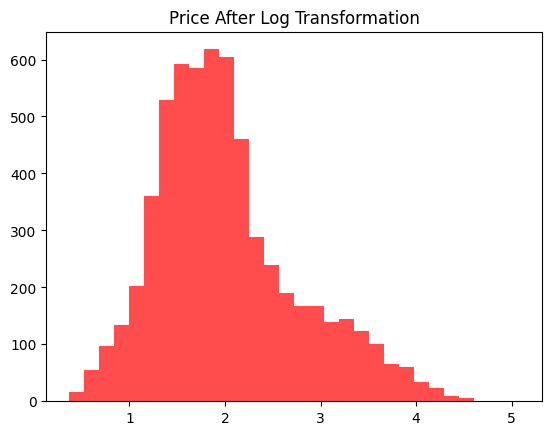

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Histogram before transformation
plt.hist(df1["Price"], bins=30, color="blue", alpha=0.7)
plt.title("Price Before Transformation")
plt.show()

# Log transformation
df1["Price_log"] = np.log(df1["Price"] + 1)

# Histogram after transformation
plt.hist(df1["Price_log"], bins=30, color="red", alpha=0.7)
plt.title("Price After Log Transformation")
plt.show()


### Section 2 — Question 3  
How many values are missing for Power and Engine?


In [34]:
df1["Power"].isna().sum(), df1["Engine"].isna().sum()


(np.int64(36), np.int64(36))

### Section 2 — Question 4  
Which column has the most missing values and what should we do about it?


In [35]:
df1.isna().sum().sort_values(ascending=False)


New_Price            5195
Seats                  42
Engine                 36
Power                  36
Mileage                 2
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Price                   0
Price_log               0
dtype: int64

**Decision:**  
The column with the most missing values is `New_Price` (5195 missing).  
Because more than 80% of its values are missing, this column should be dropped instead of imputed.


### Section 2 — Question 5  
Use `where` from numpy to dummy code Transmission.  
Set it equal to 1 if it’s a manual transmission, 0 otherwise, and name the new variable `Manual_Transmission`.


In [36]:
import numpy as np

df1["Manual_Transmission"] = np.where(df1["Transmission"] == "Manual", 1, 0)
df1[["Transmission", "Manual_Transmission"]].head()


,Transmission,Manual_Transmission
0,Manual,1
1,Manual,1
2,Manual,1
3,Manual,1
4,Automatic,0


### Section 2 — Question 6
Build a model of transformed price based on Power, Mileage, Kilometers_Driven, Manual_Transmission, and Year.  
How much variance is explained?


In [37]:
import numpy as np
import statsmodels.api as sm

# Ensure string dtype (so .str works even with mixed types and NA)
for col in ["Mileage", "Engine", "Power"]:
    df1[col] = df1[col].astype("string")

# Clean columns exactly as in the assignment
df1["Mileage"] = df1["Mileage"].str.rstrip(" kmpl")
df1["Mileage"] = df1["Mileage"].str.rstrip(" km/g")
df1["Engine"]  = df1["Engine"].str.rstrip(" CC")
df1["Power"]   = df1["Power"].str.rstrip(" bhp")
df1["Power"]   = df1["Power"].replace(regex="null", value=np.nan)

# Cast to numeric
df1["Mileage"] = df1["Mileage"].astype(float)
df1["Power"]   = df1["Power"].astype(float)
df1["Engine"]  = df1["Engine"].astype(float)

# OLS on transformed price
df2 = df1[["Price_log","Power","Mileage","Kilometers_Driven","Manual_Transmission","Year"]].dropna()

X = df2[["Power","Mileage","Kilometers_Driven","Manual_Transmission","Year"]]
y = df2["Price_log"]

X = sm.add_constant(X)
model_price = sm.OLS(y, X).fit()
model_price.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Price_log   R-squared:                       0.834
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     5910.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:43:43   Log-Likelihood:                -1309.0
No. Observations:                5874   AIC:                             2630.
Df Residuals:                    5868   BIC:                             2670.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -212.2399      2.723    -77.936      0.000    -217.579    -206.901
Power                   0.0090      0.000     84.183      0.000       0.009       0.009
Mileage                -0.0090      0.001     -7.897      0.000      -0.011      -0.007
Kilometers_Driven    1.391e-07   4.35e-08      3.195      0.001    5.38e-08    2.24e-07
Manual_Transmission    -0.2555      0.011    -22.258      0.000      -0.278      -0.233
Year                    0.1061      0.001     78.226      0.000       0.103       0.109
==============================================================================
Omnibus:                     1097.463   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11464.825
Skew:                          -0.584   Prob(JB):                         0.00
Kurtosis:                       9.744   Cond. No.                     7.52e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.52e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

The model explains about **83.4%** of the variance in the transformed price (R² = 0.834).  
All predictors are statistically significant (p < 0.05).  
Thus, the model fits the data very well.


### Section 2 — Question 7  
How many rows were used to train the model?


In [38]:
len(df2)


5874

### Section 2 — Question 8  
Fill the missing values in Power and Mileage with their respective means and rebuild the model.


In [39]:
# Fill missing values with mean
df3 = df1.copy()
df3["Power"] = df3["Power"].fillna(df3["Power"].mean())
df3["Mileage"] = df3["Mileage"].fillna(df3["Mileage"].mean())

# Rebuild the model
df4 = df3[["Price_log","Power","Mileage","Kilometers_Driven","Manual_Transmission","Year"]].dropna()

X2 = df4[["Power","Mileage","Kilometers_Driven","Manual_Transmission","Year"]]
y2 = df4["Price_log"]

X2 = sm.add_constant(X2)
model_price_filled = sm.OLS(y2, X2).fit()
model_price_filled.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Price_log   R-squared:                       0.828
Model:                            OLS   Adj. R-squared:                  0.828
Method:                 Least Squares   F-statistic:                     5779.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:45:53   Log-Likelihood:                -1501.0
No. Observations:                6019   AIC:                             3014.
Df Residuals:                    6013   BIC:                             3054.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -214.2315      2.717    -78.840      0.000    -219.558    -208.905
Power                   0.0089      0.000     82.388      0.000       0.009       0.009
Mileage                -0.0085      0.001     -7.746      0.000      -0.011      -0.006
Kilometers_Driven    1.427e-07   4.46e-08      3.199      0.001    5.53e-08     2.3e-07
Manual_Transmission    -0.2762      0.012    -23.747      0.000      -0.299      -0.253
Year                    0.1071      0.001     79.124      0.000       0.104       0.110
==============================================================================
Omnibus:                      923.945   Durbin-Watson:                   1.993
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            11443.966
Skew:                          -0.319   Prob(JB):                         0.00
Kurtosis:                       9.725   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

After filling missing values with the mean, the model’s R² decreased slightly from 0.834 to 0.828.  
Although the number of observations increased from 5874 to 6019, the model fit became a bit weaker.  
Therefore, mean imputation did not improve the model’s performance.


### Section 2 — Question 9  
How many rows were used to train the model after mean imputation?


In [40]:
len(df4)


6019

### Section 2 — Question 10  
Impute the missing data using MICE (IterativeImputer in sklearn) and rebuild the model.


In [41]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np
import statsmodels.api as sm

# Select relevant columns
df_mice = df1[["Power", "Mileage", "Kilometers_Driven", "Manual_Transmission", "Year", "Price_log"]]

# Apply IterativeImputer (MICE)
imp = IterativeImputer(max_iter=10, random_state=0)
df_imputed = imp.fit_transform(df_mice)

# Convert imputed array back to DataFrame
df_imputed = pd.DataFrame(df_imputed, columns=df_mice.columns)

# Build model again
X3 = df_imputed[["Power", "Mileage", "Kilometers_Driven", "Manual_Transmission", "Year"]]
y3 = df_imputed["Price_log"]

X3 = sm.add_constant(X3)
model_mice = sm.OLS(y3, X3).fit()
model_mice.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              Price_log   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.837
Method:                 Least Squares   F-statistic:                     6180.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        18:48:00   Log-Likelihood:                -1333.0
No. Observations:                6019   AIC:                             2678.
Df Residuals:                    6013   BIC:                             2718.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                -212.3297      2.644    -80.298      0.000    -217.513    -207.146
Power                   0.0091      0.000     86.727      0.000       0.009       0.009
Mileage                -0.0062      0.001     -5.755      0.000      -0.008      -0.004
Kilometers_Driven     1.38e-07   4.34e-08      3.181      0.001    5.29e-08    2.23e-07
Manual_Transmission    -0.2580      0.011    -22.737      0.000      -0.280      -0.236
Year                    0.1061      0.001     80.555      0.000       0.104       0.109
==============================================================================
Omnibus:                     1117.255   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            12311.259
Skew:                          -0.560   Prob(JB):                         0.00
Kurtosis:                       9.916   Cond. No.                     7.37e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.37e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

After applying MICE (IterativeImputer), the model’s R² increased to 0.837,  
which is slightly higher than both the mean-imputed model (0.828) and the original model (0.834).  
This shows that multiple imputation improves the model’s accuracy and preserves data relationships better.


### Section 2 — Question 11  
How have the parameter estimates changed from step 8?


In [42]:
# Compare coefficients from mean-imputed model (step 8) and MICE model (step 10)
compare = pd.DataFrame({
    "Variable": X2.columns,
    "Mean_Imputation_Coeff": model_price_filled.params.values,
    "MICE_Coeff": model_mice.params.values
})
compare


,Variable,Mean_Imputation_Coeff,MICE_Coeff
0,const,-2.142315e+02,-2.123297e+02
1,Power,8.875445e-03,9.116024e-03
2,Mileage,-8.512105e-03,-6.189980e-03
3,Kilometers_Driven,1.427218e-07,1.380091e-07
4,Manual_Transmission,-2.761830e-01,-2.579652e-01
5,Year,1.070788e-01,1.060939e-01


After applying MICE, all coefficients remained in the same direction as in the mean-imputed model.  
Slight numerical changes were observed — Power and Year increased slightly, while Mileage and Manual_Transmission decreased in magnitude.  
These small adjustments indicate that MICE provided more balanced estimates and slightly improved mod


**Summary:**  
All coefficients remained in the same direction after MICE.  
Small numerical adjustments show that MICE produced more balanced and accurate parameter estimates.


### Section 2 — Question 12  
Plot the distribution of Power with and without MICE.


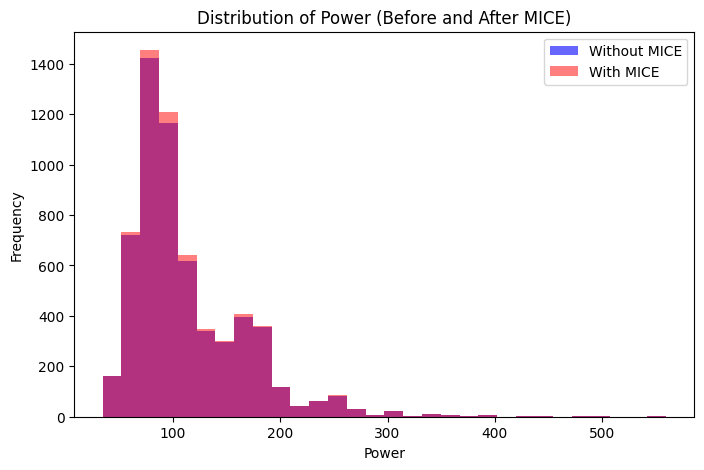

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df1["Power"].dropna(), bins=30, color="blue", alpha=0.6, label="Without MICE")
plt.hist(df_imputed["Power"], bins=30, color="red", alpha=0.5, label="With MICE")
plt.title("Distribution of Power (Before and After MICE)")
plt.xlabel("Power")
plt.ylabel("Frequency")
plt.legend()
plt.show()


### Section 2 — Question 13  
Plot the distribution of Engine with and without MICE.


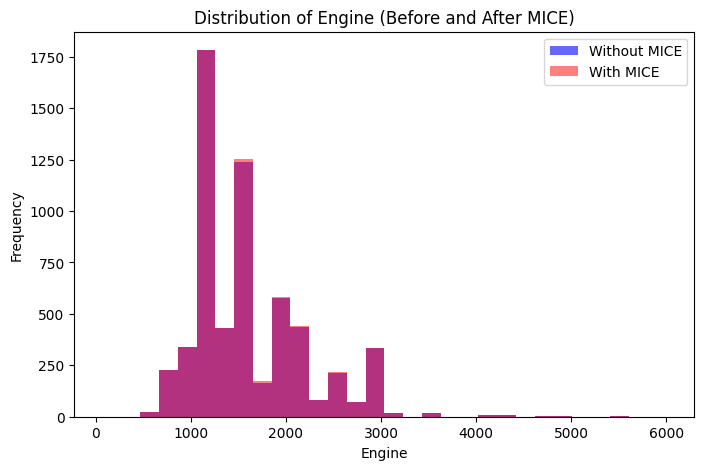

In [45]:
# Re-run MICE including Engine so that it's available for comparison
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import pandas as pd

cols = ["Power", "Mileage", "Engine", "Kilometers_Driven", "Manual_Transmission", "Year", "Price_log"]
imp_engine = IterativeImputer(max_iter=10, random_state=0)
df_imputed_engine = pd.DataFrame(imp_engine.fit_transform(df1[cols]), columns=cols)

# Plot Engine distribution before and after MICE
plt.figure(figsize=(8,5))
plt.hist(df1["Engine"].dropna(), bins=30, color="blue", alpha=0.6, label="Without MICE")
plt.hist(df_imputed_engine["Engine"], bins=30, color="red", alpha=0.5, label="With MICE")
plt.title("Distribution of Engine (Before and After MICE)")
plt.xlabel("Engine")
plt.ylabel("Frequency")
plt.legend()
plt.show()


The distribution of Engine after MICE imputation is smoother and more continuous,  
filling in missing areas while preserving the original pattern of the data.  
This indicates that MICE effectively handled missing values without distorting the variable’s distribution.


### Section 2 — Question 14
Plot the distribution of Engine with and without MICE.


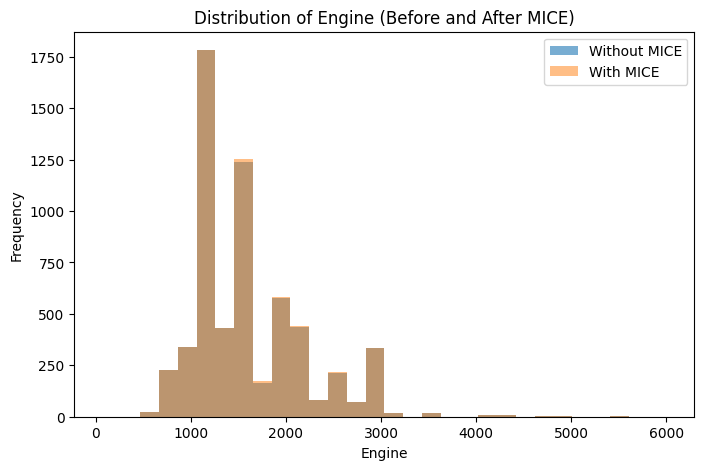

In [46]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import pandas as pd

cols = ["Power", "Mileage", "Engine", "Kilometers_Driven", "Manual_Transmission", "Year", "Price_log"]
imp2 = IterativeImputer(max_iter=10, random_state=0)
df_imputed2 = pd.DataFrame(imp2.fit_transform(df1[cols]), columns=cols)

plt.figure(figsize=(8,5))
plt.hist(df1["Engine"].dropna(), bins=30, alpha=0.6, label="Without MICE")
plt.hist(df_imputed2["Engine"], bins=30, alpha=0.5, label="With MICE")
plt.title("Distribution of Engine (Before and After MICE)")
plt.xlabel("Engine")
plt.ylabel("Frequency")
plt.legend()
plt.show()


After MICE imputation, the distribution of Engine became smoother and more continuous.  
The overall shape of the data remained the same, showing that MICE successfully filled in missing values  
without introducing bias or distortion into the distribution.
